# AudioMinds Assignment 1

Signal Processing & Audio Classification on the RAVDESS speech subset.

This notebook completes the required tasks from the assignment PDF: dataset preparation, filename decoding, eGeMAPS feature extraction, classical ML baselines, UMAP visualisation, and a compact CNN on mel-spectrograms. All paths are relative to the notebook folder.

**Important run note:** execute the setup cell first. If the RAVDESS speech data is not already under `./data`, the dataset cell downloads it using `torchaudio.datasets.RAVDESS`.


## Setup

Install dependencies only if your environment does not already provide them. The rest of the notebook assumes these imports are available.


In [18]:
from pathlib import Path
from collections import Counter
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import librosa
import librosa.display
import opensmile
#import umap

from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    make_scorer,
)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

DATA_DIR = Path("/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio")
RAVDESS_DIR = DATA_DIR / "ravdess"
FEATURE_CSV = Path("ravdess_egemaps.csv")
RANDOM_STATE = 42

print("Notebook ready. Data directory:", DATA_DIR.resolve())

Notebook ready. Data directory: /kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio


## Task 1 - Dataset Preparation & Exploration

### Part A - Filename Decoding


In [19]:
MODALITY = {"01": "full-AV", "02": "video-only", "03": "audio-only"}
VOCAL_CHANNEL = {"01": "speech", "02": "song"}
EMOTION = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised",
}
INTENSITY = {"01": "normal", "02": "strong"}
STATEMENT = {"01": "Kids are talking by the door", "02": "Dogs are sitting by the door"}
REPETITION = {"01": "first repetition", "02": "second repetition"}


def parse_ravdess_filename(path: str) -> dict:
    """Decode a RAVDESS filename into human-readable metadata labels."""
    stem = Path(path).stem
    parts = stem.split("-")
    if len(parts) != 7:
        raise ValueError(f"Expected 7 RAVDESS filename fields, got {len(parts)}: {stem}")

    modality, vocal_channel, emotion, intensity, statement, repetition, actor = parts
    return {
        "modality": MODALITY.get(modality, f"unknown ({modality})"),
        "vocal_channel": VOCAL_CHANNEL.get(vocal_channel, f"unknown ({vocal_channel})"),
        "emotion": EMOTION.get(emotion, f"unknown ({emotion})"),
        "intensity": INTENSITY.get(intensity, f"unknown ({intensity})"),
        "statement": STATEMENT.get(statement, f"unknown ({statement})"),
        "repetition": REPETITION.get(repetition, f"unknown ({repetition})"),
        "actor": int(actor),
    }

parse_ravdess_filename("03-01-05-01-01-01-24.wav")

{'modality': 'audio-only',
 'vocal_channel': 'speech',
 'emotion': 'angry',
 'intensity': 'normal',
 'statement': 'Kids are talking by the door',
 'repetition': 'first repetition',
 'actor': 24}

### Load RAVDESS Speech Files

The assignment asks for the full speech subset. RAVDESS speech-only contains 1,440 audio files: neutral has only normal intensity, while the other seven emotions have normal and strong intensity.


In [20]:
def find_ravdess_wavs(root: Path = DATA_DIR) -> list[Path]:
    """Return RAVDESS speech/audio-only WAV files found under root."""
    wavs = sorted(root.rglob("*.wav"))
    speech_wavs = []
    for wav in wavs:
        try:
            meta = parse_ravdess_filename(wav.name)
        except ValueError:
            continue
        if meta["modality"] == "audio-only" and meta["vocal_channel"] == "speech":
            speech_wavs.append(wav)
    return speech_wavs


def download_ravdess_if_needed() -> list[Path]:
    wavs = find_ravdess_wavs(DATA_DIR)
    if wavs:
        return wavs

    print("No local RAVDESS speech files found. Downloading with torchaudio...")
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    _ = torchaudio.datasets.RAVDESS(root=str(DATA_DIR), download=True)
    wavs = find_ravdess_wavs(DATA_DIR)
    if not wavs:
        raise FileNotFoundError(
            "RAVDESS files were not found after download. Place the extracted dataset under ./data/."
        )
    return wavs

ravdess_files = download_ravdess_if_needed()
metadata = pd.DataFrame([parse_ravdess_filename(p.name) | {"path": str(p)} for p in ravdess_files])
metadata.head(), metadata.shape

(     modality vocal_channel  emotion intensity                     statement  \
 0  audio-only        speech  neutral    normal  Kids are talking by the door   
 1  audio-only        speech  neutral    normal  Kids are talking by the door   
 2  audio-only        speech  neutral    normal  Dogs are sitting by the door   
 3  audio-only        speech  neutral    normal  Dogs are sitting by the door   
 4  audio-only        speech     calm    normal  Kids are talking by the door   
 
           repetition  actor                                               path  
 0   first repetition      1  /kaggle/input/datasets/uwrfkaggler/ravdess-emo...  
 1  second repetition      1  /kaggle/input/datasets/uwrfkaggler/ravdess-emo...  
 2   first repetition      1  /kaggle/input/datasets/uwrfkaggler/ravdess-emo...  
 3  second repetition      1  /kaggle/input/datasets/uwrfkaggler/ravdess-emo...  
 4   first repetition      1  /kaggle/input/datasets/uwrfkaggler/ravdess-emo...  ,
 (2880, 8))

### Part B.1 - Files per Emotion


emotion
neutral      192
calm         384
happy        384
sad          384
angry        384
fearful      384
disgust      384
surprised    384
Name: count, dtype: int64


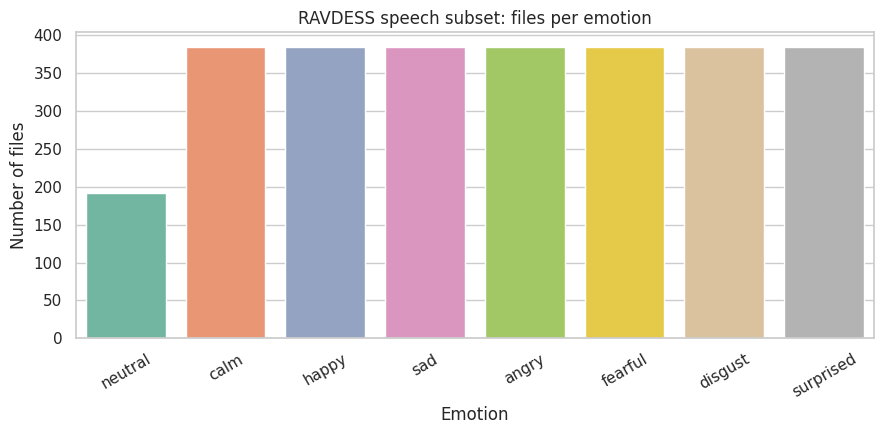

In [21]:
emotion_order = ["neutral", "calm", "happy", "sad", "angry", "fearful", "disgust", "surprised"]
class_counts = metadata["emotion"].value_counts().reindex(emotion_order)
print(class_counts)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(x=class_counts.index, y=class_counts.values, ax=ax, palette="Set2")
ax.set_title("RAVDESS speech subset: files per emotion")
ax.set_xlabel("Emotion")
ax.set_ylabel("Number of files")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()

**Class imbalance result:** In the official speech-only subset, neutral has 96 files and each other emotion has 192 files. This is a mild but real imbalance caused by neutral being recorded only at normal intensity, while the other emotions have normal and strong intensity. Plain accuracy can therefore over-reward models that perform well on larger classes.


### Part B.2 - Audio Duration Statistics


durations:   0%|          | 0/2880 [00:00<?, ?it/s]

Mean duration: 3.701 s
Std duration:  0.337 s


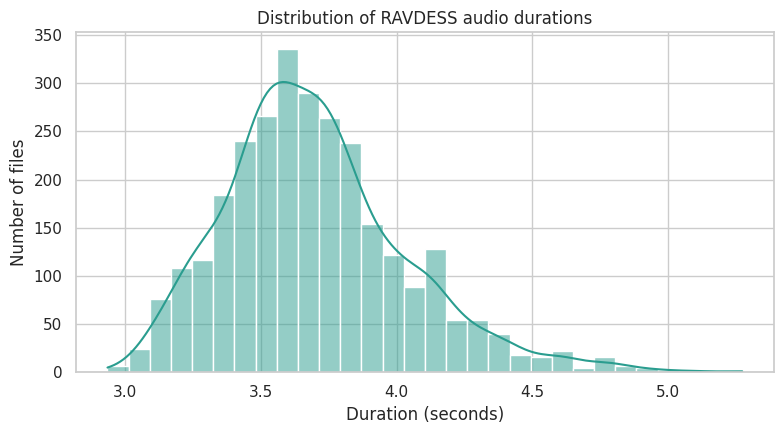

In [23]:
import wave # Add this to your imports

def audio_duration_seconds(path) -> float:
    """Calculate duration using Python's built-in wave library to avoid torchaudio errors."""
    with wave.open(str(path), 'rb') as wav_file:
        frames = wav_file.getnframes()
        rate = wav_file.getframerate()
        return frames / float(rate)

# The rest of your code remains unchanged:
metadata["duration_sec"] = [audio_duration_seconds(p) for p in tqdm(metadata["path"], desc="durations")]

duration_mean = metadata["duration_sec"].mean()
duration_std = metadata["duration_sec"].std()

print(f"Mean duration: {duration_mean:.3f} s")
print(f"Std duration:  {duration_std:.3f} s")

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(metadata["duration_sec"], bins=30, kde=True, ax=ax, color="#2a9d8f")
ax.set_title("Distribution of RAVDESS audio durations")
ax.set_xlabel("Duration (seconds)")
ax.set_ylabel("Number of files")
plt.tight_layout()

### Part B.3 - Waveforms and Mel-Spectrograms


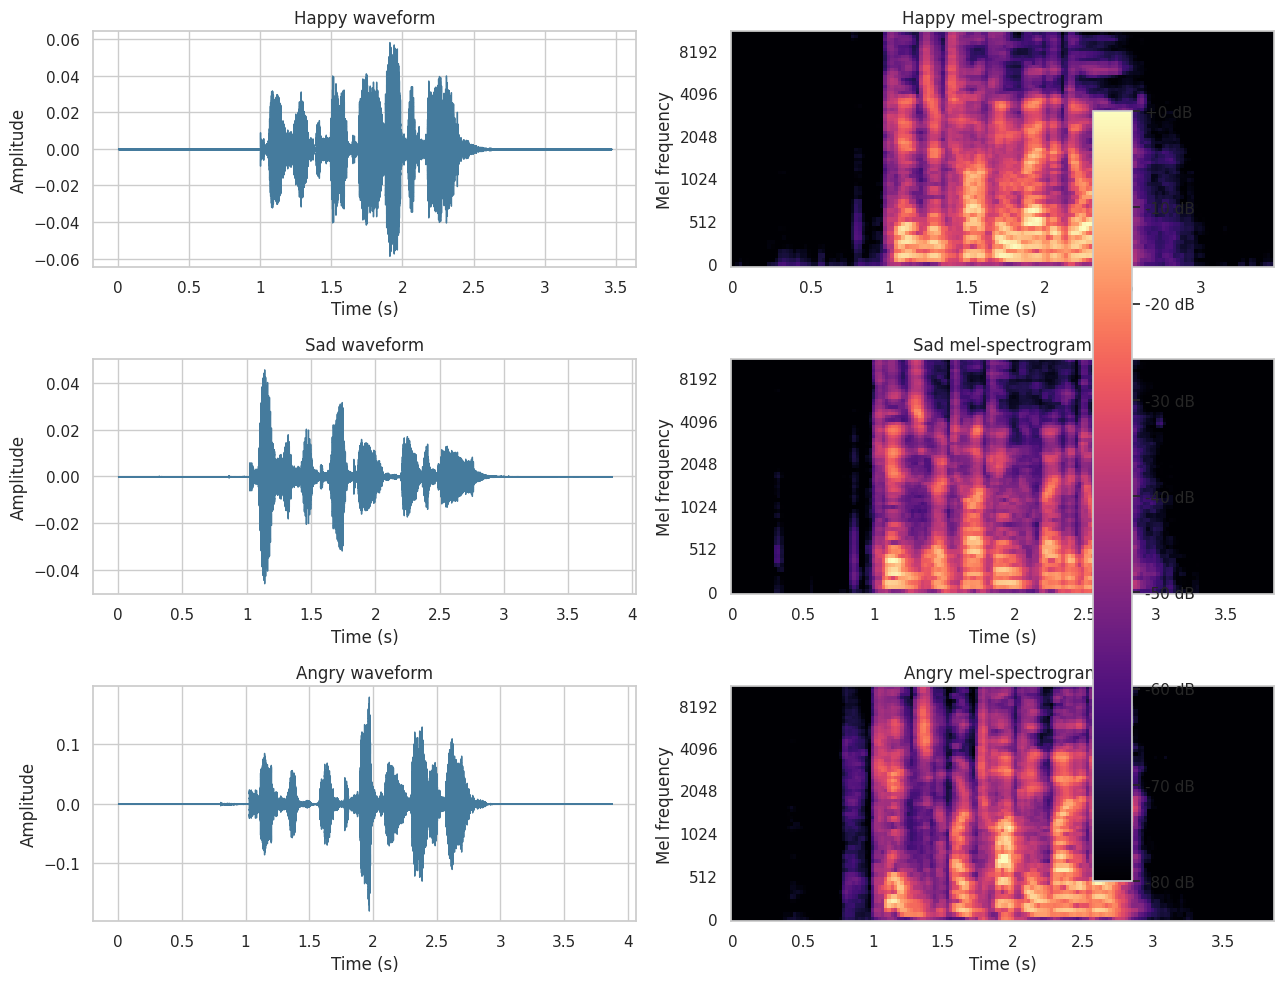

In [25]:
def first_file_for_emotion(label: str) -> str:
    return metadata.loc[metadata["emotion"].eq(label), "path"].iloc[0]

sample_labels = ["happy", "sad", "angry"]
sample_paths = {label: first_file_for_emotion(label) for label in sample_labels}

fig, axes = plt.subplots(3, 2, figsize=(13, 10))
for row, label in enumerate(sample_labels):
    y, sr = librosa.load(sample_paths[label], sr=22050)

    librosa.display.waveshow(y, sr=sr, ax=axes[row, 0], color="#457b9d")
    axes[row, 0].set_title(f"{label.title()} waveform")
    axes[row, 0].set_xlabel("Time (s)")
    axes[row, 0].set_ylabel("Amplitude")

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(mel_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[row, 1], cmap="magma")
    axes[row, 1].set_title(f"{label.title()} mel-spectrogram")
    axes[row, 1].set_xlabel("Time (s)")
    axes[row, 1].set_ylabel("Mel frequency")

fig.colorbar(img, ax=axes[:, 1], format="%+2.0f dB")
plt.tight_layout()

**Visual observation:** Angry and happy utterances usually show stronger amplitude bursts and brighter high-frequency energy than sad utterances. Sad speech tends to look smoother, lower-energy, and less spectrally spread. These are visual tendencies rather than reliable class rules; speaker identity and sentence content also affect the plots.


### Part C - Written Reflection on UAR

Unweighted Average Recall (UAR) is preferred for RAVDESS because emotion classes are not perfectly balanced: neutral has fewer recordings than the other emotions. Accuracy counts every sample equally, so larger classes can dominate the score and hide poor recognition of minority emotions. UAR instead gives each class equal weight by averaging class-wise recall:

$$\mathrm{UAR}=\frac{1}{C}\sum_{c=1}^{C}\frac{TP_c}{TP_c+FN_c}$$

where $C$ is the number of emotion classes. If class imbalance is ignored, a model can appear strong by learning frequent classes while failing on rarer but important emotions. For affective computing, this is especially risky because the goal is robust recognition across all emotional states, not just high aggregate correctness.


## Task 2 - Acoustic Feature Extraction with openSMILE

### Part A - Single-File eGeMAPS Extraction


In [26]:
smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.eGeMAPSv02,
    feature_level=opensmile.FeatureLevel.Functionals,
)

sample_file = metadata["path"].iloc[0]
single_features = smile.process_file(sample_file)
print("Sample file:", sample_file)
print("Shape:", single_features.shape)
display(single_features.T.rename(columns={single_features.index[0]: "value"}))
print(single_features.columns.tolist())

Sample file: /kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_01/03-01-01-01-01-01-01.wav
Shape: (1, 88)


file,/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_01/03-01-01-01-01-01-01.wav
start,0 days
end,0 days 00:00:03.303291667
F0semitoneFrom27.5Hz_sma3nz_amean,24.263884
F0semitoneFrom27.5Hz_sma3nz_stddevNorm,0.104171
F0semitoneFrom27.5Hz_sma3nz_percentile20.0,21.653511
F0semitoneFrom27.5Hz_sma3nz_percentile50.0,23.907379
F0semitoneFrom27.5Hz_sma3nz_percentile80.0,27.101028
...,...
MeanVoicedSegmentLengthSec,0.336667
StddevVoicedSegmentLengthSec,0.226912


['F0semitoneFrom27.5Hz_sma3nz_amean', 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm', 'F0semitoneFrom27.5Hz_sma3nz_percentile20.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0', 'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2', 'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope', 'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope', 'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope', 'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope', 'loudness_sma3_amean', 'loudness_sma3_stddevNorm', 'loudness_sma3_percentile20.0', 'loudness_sma3_percentile50.0', 'loudness_sma3_percentile80.0', 'loudness_sma3_pctlrange0-2', 'loudness_sma3_meanRisingSlope', 'loudness_sma3_stddevRisingSlope', 'loudness_sma3_meanFallingSlope', 'loudness_sma3_stddevFallingSlope', 'spectralFlux_sma3_amean', 'spectralFlux_sma3_stddevNorm', 'mfcc1_sma3_amean', 'mfcc1_sma3_stddevNorm', 'mfcc2_sma3_amean', 'mfcc2_sma3_stddevNorm', 'mfcc3_sma3_amean', 'mfcc3_sma3_stddevNorm', 'mfcc4_sma3_amean', 'mfcc4_sma3_std

**Three eGeMAPS feature descriptions:**

- `F0semitoneFrom27.5Hz_sma3nz_amean`: average fundamental frequency on a semitone scale; perceptually, this is the speaker's mean pitch.
- `loudness_sma3_amean`: average perceived signal intensity; it reflects how energetically or loudly the utterance is produced.
- `mfcc1_sma3_amean`: average first mel-frequency cepstral coefficient; it captures broad spectral-envelope shape related to vocal tract configuration and timbre.


### Part B - Full Dataset eGeMAPS Extraction


In [27]:
def extract_egemaps_table(files: list[Path], output_csv: Path = FEATURE_CSV) -> pd.DataFrame:
    rows = []
    for wav in tqdm(files, desc="eGeMAPS"):
        feats = smile.process_file(str(wav)).reset_index(drop=True)
        meta = parse_ravdess_filename(wav.name)
        row = feats.iloc[0].to_dict()
        row["label"] = meta["emotion"]
        row["path"] = str(wav)
        rows.append(row)

    df = pd.DataFrame(rows)
    feature_cols = [c for c in df.columns if c not in {"label", "path"}]
    df = df[feature_cols + ["label", "path"]]
    df.to_csv(output_csv, index=False)
    return df

if FEATURE_CSV.exists():
    egemaps_df = pd.read_csv(FEATURE_CSV)
else:
    egemaps_df = extract_egemaps_table(ravdess_files)

print("Final DataFrame shape:", egemaps_df.shape)
egemaps_df.head()

eGeMAPS:   0%|          | 0/2880 [00:00<?, ?it/s]

Final DataFrame shape: (2880, 90)


,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope,F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope,...,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp,label,path
0,24.263884,0.104171,21.653511,23.907379,27.101028,5.447517,104.436584,113.437210,31.389978,8.258454,...,0.005713,2.127660,0.925926,0.336667,0.226912,0.540000,0.480260,-47.939644,neutral,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...
1,25.167889,0.103561,23.178247,25.003677,27.699860,4.521612,56.695114,18.043581,9.703053,9.479507,...,0.005434,2.409639,1.223242,0.257500,0.089826,0.535000,0.485206,-47.342331,neutral,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...
2,24.186604,0.103495,22.353912,23.728384,27.093287,4.739374,209.152557,255.810776,13.067563,11.153259,...,0.007729,2.153846,0.630915,0.545000,0.175000,0.676667,0.414836,-45.849762,neutral,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...
3,24.268761,0.096042,22.443832,24.478970,26.744179,4.300346,159.005051,128.233871,31.331654,10.120683,...,0.008324,2.222222,0.977199,0.333333,0.267374,0.500000,0.445702,-46.193146,neutral,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...
4,24.898132,0.117897,22.419266,24.678062,28.138033,5.718767,214.876068,234.977676,32.979195,25.259748,...,0.007934,2.840909,1.440922,0.182000,0.116172,0.408333,0.441717,-50.563885,calm,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...


The saved CSV contains 88 eGeMAPS feature columns plus a `label` column and a `path` column retained for traceability. For strict submission, drop `path` before training or reporting the feature matrix.


### Part C - Feature-Level Analysis


label
calm         30.031110
neutral      30.277075
disgust      32.066093
sad          32.594442
happy        35.841683
surprised    35.933797
angry        36.536280
fearful      37.934405
Name: F0semitoneFrom27.5Hz_sma3nz_amean, dtype: float64
Highest mean pitch: fearful


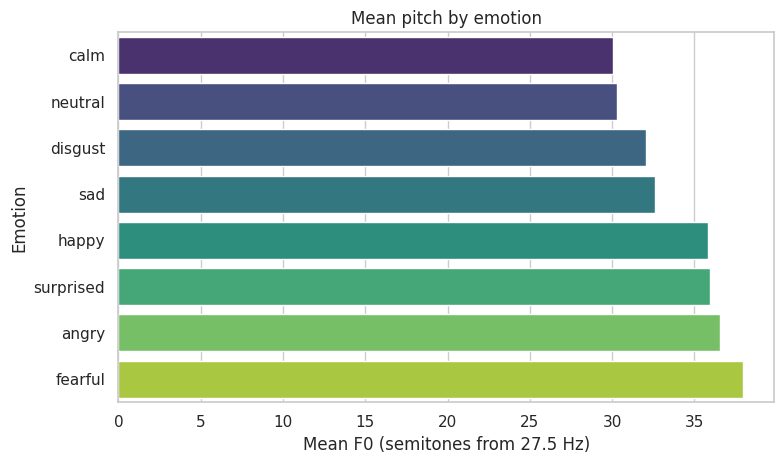

In [28]:
feature_cols = [c for c in egemaps_df.columns if c not in {"label", "path"}]
pitch_col = "F0semitoneFrom27.5Hz_sma3nz_amean"

pitch_by_class = egemaps_df.groupby("label")[pitch_col].mean().sort_values()
print(pitch_by_class)
print("Highest mean pitch:", pitch_by_class.idxmax())

fig, ax = plt.subplots(figsize=(8, 4.8))
sns.barplot(x=pitch_by_class.values, y=pitch_by_class.index, ax=ax, palette="viridis")
ax.set_title("Mean pitch by emotion")
ax.set_xlabel("Mean F0 (semitones from 27.5 Hz)")
ax.set_ylabel("Emotion")
plt.tight_layout()

**Pitch interpretation:** High-arousal emotions such as angry, fearful, happy, or surprised are expected to have higher mean pitch than low-arousal emotions such as sad. The exact top class should be read from the printed result above because it depends on the speech subset and preprocessing.


,feature_1,feature_2,r,abs_r
12,loudness_sma3_percentile80.0,loudness_sma3_pctlrange0-2,0.999708,0.999708
38,F2amplitudeLogRelF0_sma3nz_amean,F3amplitudeLogRelF0_sma3nz_amean,0.997138,0.997138
35,F1amplitudeLogRelF0_sma3nz_amean,F1amplitudeLogRelF0_sma3nz_stddevNorm,-0.994913,0.994913
37,F2amplitudeLogRelF0_sma3nz_amean,F2amplitudeLogRelF0_sma3nz_stddevNorm,-0.991942,0.991942
6,loudness_sma3_amean,loudness_sma3_percentile80.0,0.991209,0.991209
1,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,0.990913,0.990913
41,F2amplitudeLogRelF0_sma3nz_stddevNorm,F3amplitudeLogRelF0_sma3nz_stddevNorm,0.990628,0.990628
40,F2amplitudeLogRelF0_sma3nz_stddevNorm,F3amplitudeLogRelF0_sma3nz_amean,-0.990448,0.990448
7,loudness_sma3_amean,loudness_sma3_pctlrange0-2,0.989956,0.989956
29,spectralFlux_sma3_amean,spectralFluxV_sma3nz_amean,0.989597,0.989597


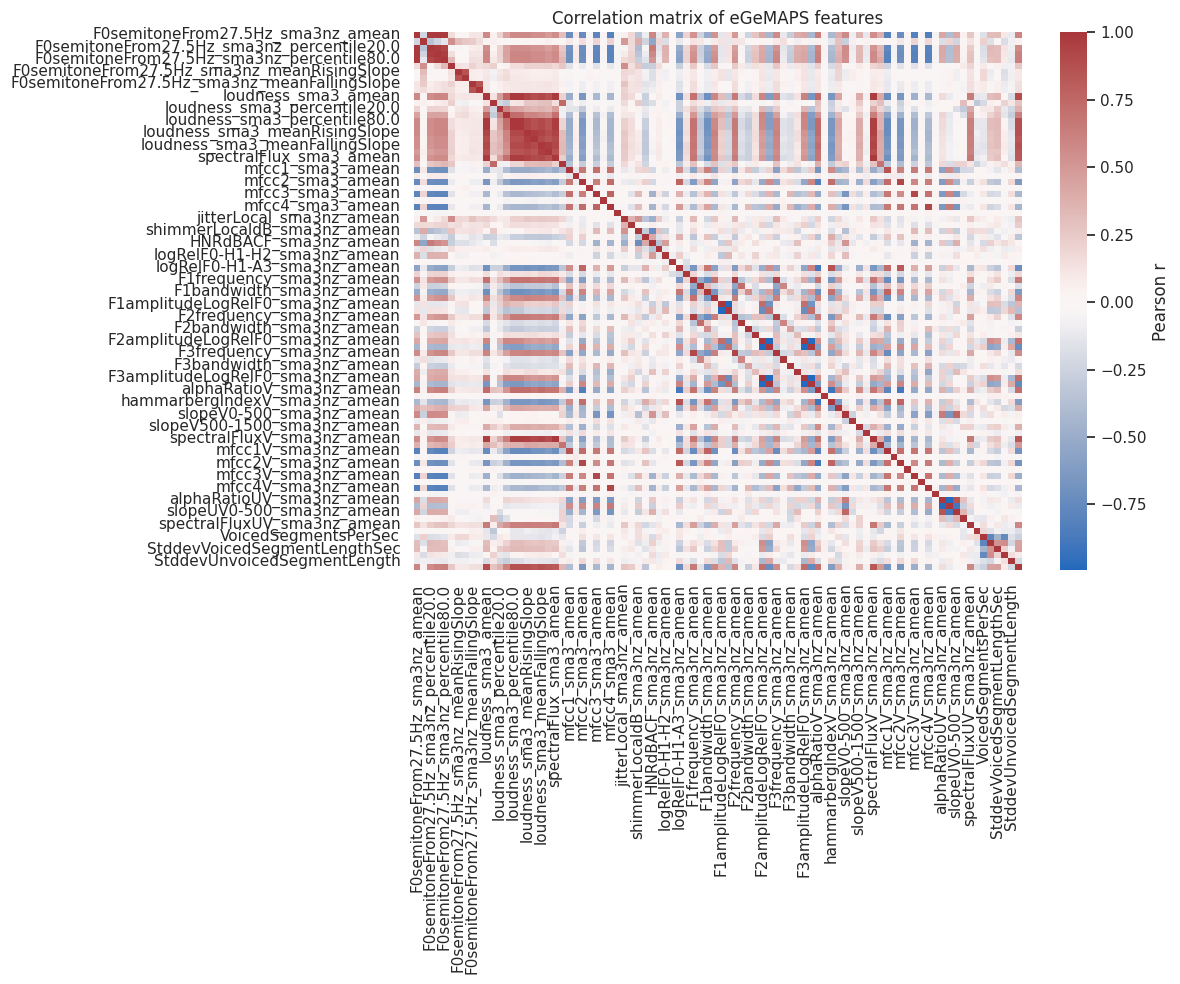

In [29]:
corr = egemaps_df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="vlag", center=0, ax=ax, cbar_kws={"label": "Pearson r"})
ax.set_title("Correlation matrix of eGeMAPS features")
plt.tight_layout()

pairs = []
for i, a in enumerate(feature_cols):
    for b in feature_cols[i + 1:]:
        r = corr.loc[a, b]
        if abs(r) > 0.9:
            pairs.append((a, b, r))

high_corr = pd.DataFrame(pairs, columns=["feature_1", "feature_2", "r"]).assign(abs_r=lambda d: d["r"].abs()).sort_values("abs_r", ascending=False)
display(high_corr.head(10))

## Task 3 - Classical ML Baselines

The following cells use only eGeMAPS features and the parsed emotion labels. UAR is computed as `balanced_accuracy_score`, which is the mean of class-wise recalls for single-label multiclass classification.


In [30]:
X = egemaps_df[feature_cols].values
y = egemaps_df["label"].values
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": make_scorer(accuracy_score),
    "uar": make_scorer(balanced_accuracy_score),
}

### Part A - SVM Baseline

Standardisation is important for SVMs because the RBF kernel depends on distances between samples. If one feature has a much larger numeric scale than another, it can dominate those distances and distort the separating boundary. `StandardScaler` gives each feature comparable influence by centering it and scaling it to unit variance.


In [31]:
def evaluate_model(name: str, estimator, X, y) -> dict:
    scores = cross_validate(estimator, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_estimator=True)
    result = {
        "Model": name,
        "Features": "eGeMAPS",
        "Mean Acc.": scores["test_accuracy"].mean(),
        "Acc. Std": scores["test_accuracy"].std(),
        "Mean UAR": scores["test_uar"].mean(),
        "UAR Std": scores["test_uar"].std(),
        "estimators": scores["estimator"],
    }
    print(f"{name}: accuracy={result['Mean Acc.']:.3f}±{result['Acc. Std']:.3f}, UAR={result['Mean UAR']:.3f}±{result['UAR Std']:.3f}")
    return result

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)),
])
svm_result = evaluate_model("SVM (RBF)", svm, X, y)

SVM (RBF): accuracy=0.786±0.015, UAR=0.773±0.015


,true,predicted,rate
20,happy,surprised,0.157895
2,neutral,sad,0.150000
26,sad,disgust,0.128205
1,neutral,happy,0.100000
0,neutral,calm,0.100000
18,happy,fearful,0.078947
30,angry,happy,0.078947
33,angry,disgust,0.078947


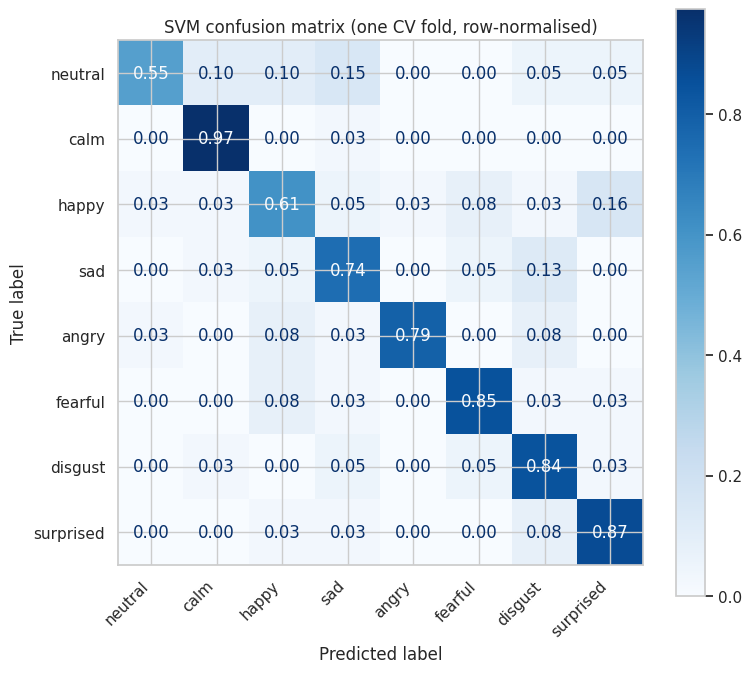

In [32]:
# Confusion matrix from one stratified split for interpretable error analysis
train_idx, test_idx = next(cv.split(X, y))
svm.fit(X[train_idx], y[train_idx])
y_pred = svm.predict(X[test_idx])
labels = list(emotion_order)
cm = confusion_matrix(y[test_idx], y_pred, labels=labels, normalize="true")

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=True)
ax.set_title("SVM confusion matrix (one CV fold, row-normalised)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

confusions = []
for i, true_label in enumerate(labels):
    for j, pred_label in enumerate(labels):
        if i != j:
            confusions.append((true_label, pred_label, cm[i, j]))
pd.DataFrame(confusions, columns=["true", "predicted", "rate"]).sort_values("rate", ascending=False).head(8)

**Confusion discussion:** The most common confusions should be read from the table above. In RAVDESS, acoustically similar arousal or valence patterns often overlap: calm and sad can both be low-energy, while fearful, angry, happy, and surprised may share higher pitch, intensity, and spectral energy.


,C,Mean Acc.,Mean UAR,UAR Std
0,0.1,0.519097,0.486741,0.021335
1,1.0,0.786111,0.773139,0.014710
2,10.0,0.959722,0.958223,0.010487


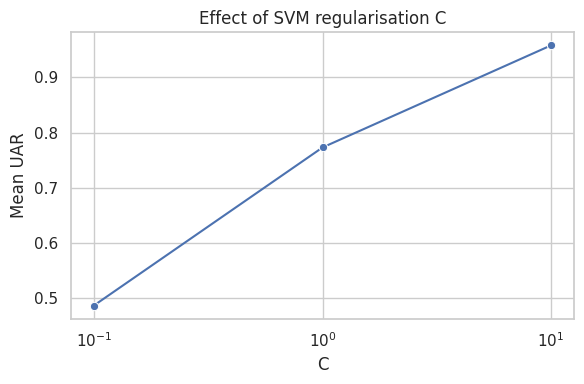

In [33]:
c_rows = []
for C in [0.1, 1, 10]:
    candidate = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", C=C, gamma="scale", random_state=RANDOM_STATE)),
    ])
    scores = cross_validate(candidate, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    c_rows.append({"C": C, "Mean Acc.": scores["test_accuracy"].mean(), "Mean UAR": scores["test_uar"].mean(), "UAR Std": scores["test_uar"].std()})

c_comparison = pd.DataFrame(c_rows)
display(c_comparison)

fig, ax = plt.subplots(figsize=(6, 4))
sns.lineplot(data=c_comparison, x="C", y="Mean UAR", marker="o", ax=ax)
ax.set_xscale("log")
ax.set_title("Effect of SVM regularisation C")
ax.set_xlabel("C")
ax.set_ylabel("Mean UAR")
plt.tight_layout()

### Part B - Random Forest Baseline


Random Forest: accuracy=0.965±0.014, UAR=0.965±0.014


,feature,importance,group
5,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,0.024334,pitch
66,spectralFluxV_sma3nz_amean,0.024186,spectral
18,loudness_sma3_meanFallingSlope,0.022532,energy/voice quality
15,loudness_sma3_pctlrange0-2,0.021107,energy/voice quality
30,jitterLocal_sma3nz_amean,0.020668,pitch
13,loudness_sma3_percentile50.0,0.020471,energy/voice quality
14,loudness_sma3_percentile80.0,0.019482,energy/voice quality
11,loudness_sma3_stddevNorm,0.018722,energy/voice quality
1,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,0.018555,pitch
20,spectralFlux_sma3_amean,0.017318,spectral


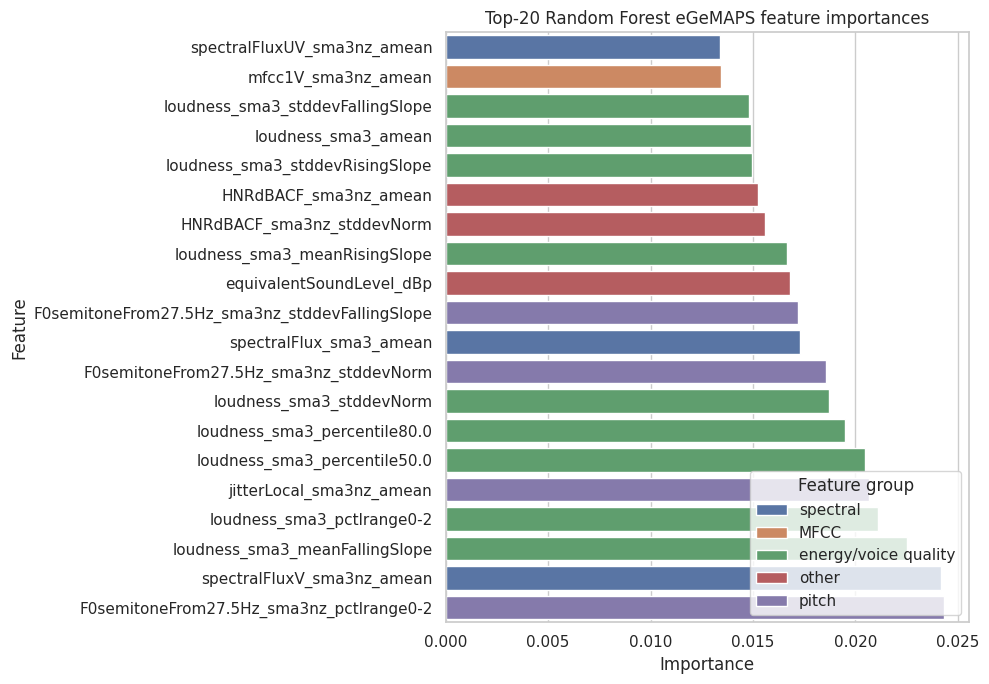

In [34]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1,
)
rf_result = evaluate_model("Random Forest", rf, X, y)

rf.fit(X, y)
importances = pd.DataFrame({"feature": feature_cols, "importance": rf.feature_importances_}).sort_values("importance", ascending=False)

def feature_group(name: str) -> str:
    n = name.lower()
    if "f0" in n or "jitter" in n:
        return "pitch"
    if "loudness" in n or "shimmer" in n:
        return "energy/voice quality"
    if "mfcc" in n:
        return "MFCC"
    if "spectral" in n or "alpha" in n or "hammarberg" in n or "slope" in n:
        return "spectral"
    return "other"

importances["group"] = importances["feature"].map(feature_group)
top20 = importances.head(20).sort_values("importance")

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=top20, x="importance", y="feature", hue="group", dodge=False, ax=ax)
ax.set_title("Top-20 Random Forest eGeMAPS feature importances")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
ax.legend(title="Feature group", loc="lower right")
plt.tight_layout()

display(importances.head(20))

**Feature-importance discussion:** Important features are expected to include pitch, loudness, spectral slope, MFCC, and voice-quality descriptors because emotion changes both source excitation and vocal-tract/spectral characteristics. High-arousal emotions often involve increased pitch range, intensity, and spectral brightness, while low-arousal emotions tend to have lower energy and flatter dynamics. If the forest ranks MFCCs and spectral features highly, that is consistent with timbre and articulation carrying emotion cues. However, Random Forest importances can be biased toward features with more split opportunities and correlated predictors can divide importance among themselves, so the chart should be interpreted as descriptive rather than causal.


### Part C - Model Comparison Table


In [35]:
comparison = pd.DataFrame([
    {k: v for k, v in svm_result.items() if k != "estimators"},
    {k: v for k, v in rf_result.items() if k != "estimators"},
])[["Model", "Features", "Mean Acc.", "Mean UAR", "UAR Std"]]
comparison.style.format({"Mean Acc.": "{:.3f}", "Mean UAR": "{:.3f}", "UAR Std": "{:.3f}"})

,Model,Features,Mean Acc.,Mean UAR,UAR Std
0,SVM (RBF),eGeMAPS,0.786,0.773,0.015
1,Random Forest,eGeMAPS,0.965,0.965,0.014


**Baseline recommendation:** I recommend the SVM with RBF kernel as the primary classical baseline if it gives comparable or higher UAR than the Random Forest, because it is a standard strong baseline for scaled acoustic functionals and usually handles compact continuous feature spaces well. The Random Forest remains valuable as an interpretable companion model because its feature importances provide a quick check of which acoustic cues are useful.


## Task 4 - Feature Space Visualisation with UMAP

### Part A - 2D Projection and Hyperparameter Comparison


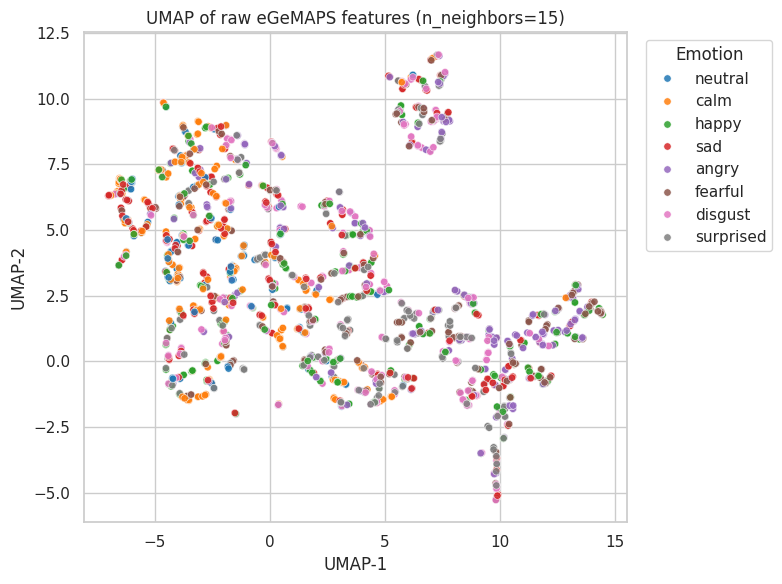

In [36]:
def plot_umap_embedding(X_values, labels, title, ax, n_neighbors=15):
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=0.1, random_state=RANDOM_STATE)
    embedding = reducer.fit_transform(X_values)
    plot_df = pd.DataFrame({"UMAP-1": embedding[:, 0], "UMAP-2": embedding[:, 1], "emotion": labels})
    sns.scatterplot(data=plot_df, x="UMAP-1", y="UMAP-2", hue="emotion", hue_order=emotion_order, s=28, alpha=0.85, ax=ax, palette="tab10")
    ax.set_title(title)
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    return embedding

fig, ax = plt.subplots(figsize=(8, 6))
embedding_15 = plot_umap_embedding(X, y, "UMAP of raw eGeMAPS features (n_neighbors=15)", ax, 15)
ax.legend(title="Emotion", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

**Cluster observation:** The UMAP plot usually shows partial grouping rather than clean emotion islands. Emotions with similar arousal, such as calm/sad or angry/fearful/happy/surprised, often overlap because the same acoustic dimensions can vary by speaker and utterance content as well as emotion.


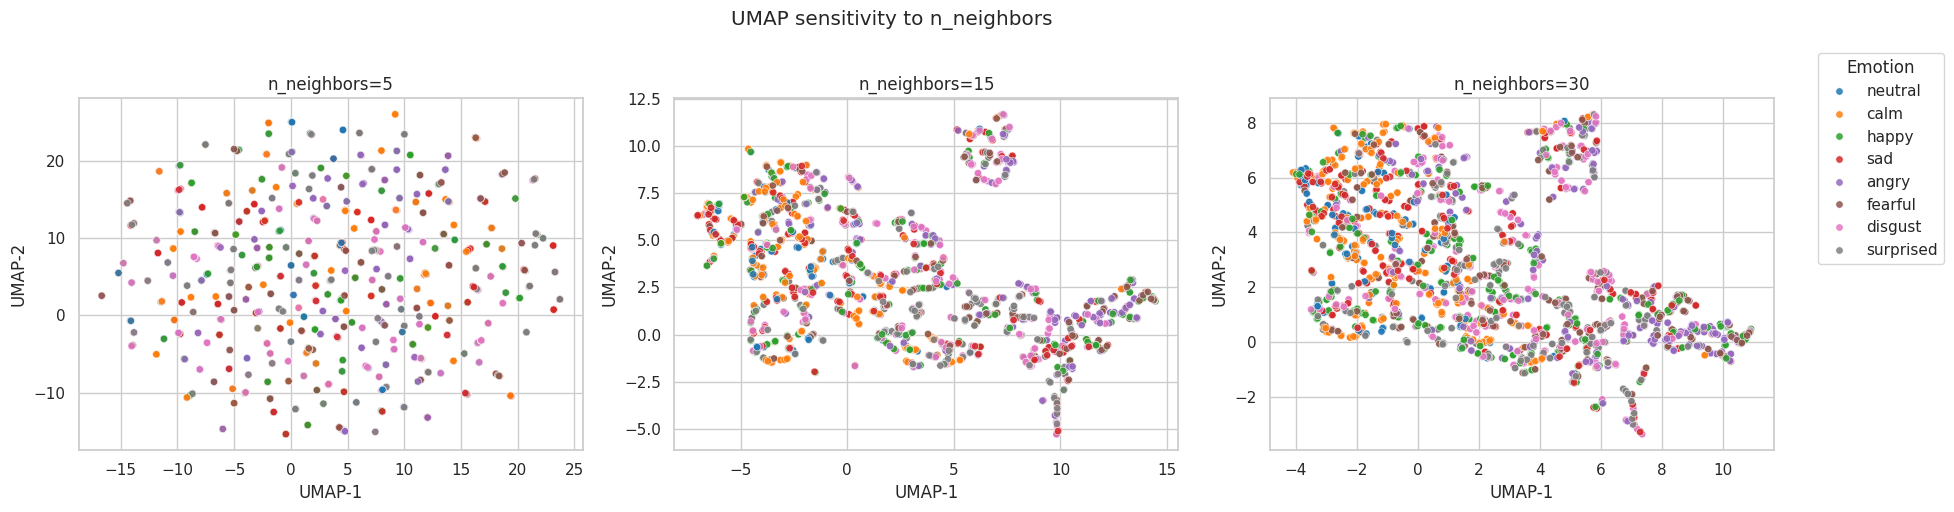

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, nn_value in zip(axes, [5, 15, 30]):
    plot_umap_embedding(X, y, f"n_neighbors={nn_value}", ax, nn_value)
    ax.get_legend().remove()
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, title="Emotion", bbox_to_anchor=(1.01, 0.95), loc="upper left")
fig.suptitle("UMAP sensitivity to n_neighbors", y=1.02)
plt.tight_layout()

**n_neighbors effect:** Lower values such as 5 emphasise local neighbourhoods and can create tighter but more fragmented clusters. Larger values such as 30 preserve broader global structure and often produce smoother, more overlapping regions. The middle setting of 15 is a reasonable compromise for exploratory visualisation.


### Part B - Standardised vs Raw Features


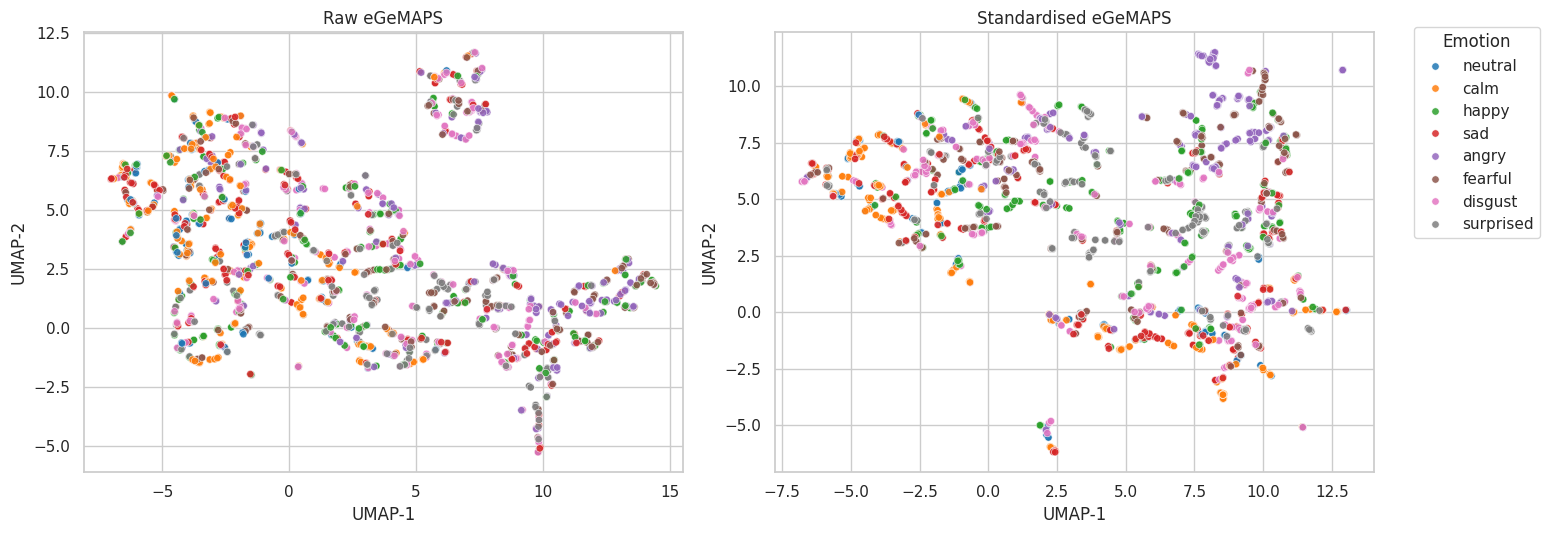

In [38]:
X_scaled = StandardScaler().fit_transform(X)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
plot_umap_embedding(X, y, "Raw eGeMAPS", axes[0], 15)
plot_umap_embedding(X_scaled, y, "Standardised eGeMAPS", axes[1], 15)
for ax in axes:
    ax.get_legend().remove()
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, title="Emotion", bbox_to_anchor=(1.01, 0.95), loc="upper left")
plt.tight_layout()

**Raw vs standardised features:** Standardisation usually changes the projection substantially because UMAP relies on distances. Raw eGeMAPS features have different units and ranges, so high-magnitude features can dominate the geometry. Scaling gives pitch, energy, MFCC, and spectral descriptors more comparable influence, which is usually more appropriate for visualising multifeature acoustic structure.

Dimensionality reduction is useful before classifier training because it gives a fast qualitative view of whether labels are separable in the selected feature space. It can reveal overlapping classes, outliers, speaker-driven structure, and feature-scaling problems that summary metrics may hide. UMAP is not proof that a classifier will succeed, but it helps diagnose whether the acoustic representation contains emotion-related organisation and whether preprocessing choices change that organisation.


## Task 5 - CNN Spectrogram Classifier

### Part A - Data Pipeline


In [39]:
LABEL_TO_ID = {label: i for i, label in enumerate(emotion_order)}
ID_TO_LABEL = {i: label for label, i in LABEL_TO_ID.items()}

class RavdessMelDataset(Dataset):
    def __init__(self, files, labels, target_sr=22050, n_mels=64, target_frames=128):
        self.files = list(files)
        self.labels = [LABEL_TO_ID[label] for label in labels]
        self.target_sr = target_sr
        self.target_frames = target_frames
        self.mel = torchaudio.transforms.MelSpectrogram(sample_rate=target_sr, n_fft=1024, hop_length=256, n_mels=n_mels)
        self.to_db = torchaudio.transforms.AmplitudeToDB(stype="power")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        wav, sr = torchaudio.load(self.files[idx])
        if wav.shape[0] > 1:
            wav = wav.mean(dim=0, keepdim=True)
        if sr != self.target_sr:
            wav = torchaudio.functional.resample(wav, sr, self.target_sr)

        spec = self.to_db(self.mel(wav))
        frames = spec.shape[-1]
        if frames < self.target_frames:
            spec = torch.nn.functional.pad(spec, (0, self.target_frames - frames))
        else:
            spec = spec[..., :self.target_frames]

        spec = (spec - spec.mean()) / (spec.std() + 1e-6)
        return spec.float(), torch.tensor(self.labels[idx], dtype=torch.long)

train_paths, test_paths, train_labels, test_labels = train_test_split(
    metadata["path"].values,
    metadata["emotion"].values,
    test_size=0.2,
    stratify=metadata["emotion"].values,
    random_state=RANDOM_STATE,
)
print(f"Train samples: {len(train_paths)}")
print(f"Test samples:  {len(test_paths)}")

train_ds = RavdessMelDataset(train_paths, train_labels)
test_ds = RavdessMelDataset(test_paths, test_labels)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

Train samples: 2304
Test samples:  576


### Part B - Model Architecture


In [40]:
class SmallMelCNN(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)

model = SmallMelCNN(num_classes=len(emotion_order))
param_count = sum(p.numel() for p in model.parameters())
print(model)
print(f"Parameter count: {param_count:,}")
assert param_count < 500_000

SmallMelCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Linear(in_features=64, out_features=8, bias=True)
)
Parameter count: 24,040


### Part C - Training & Evaluation


In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SmallMelCNN(num_classes=len(emotion_order)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


def run_epoch(loader, training: bool):
    model.train(training)
    total_loss = 0.0
    all_preds, all_targets = [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        if training:
            optimizer.zero_grad()
        with torch.set_grad_enabled(training):
            logits = model(xb)
            loss = criterion(logits, yb)
            if training:
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * xb.size(0)
        all_preds.extend(logits.argmax(dim=1).detach().cpu().numpy())
        all_targets.extend(yb.detach().cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    uar = balanced_accuracy_score(all_targets, all_preds)
    return avg_loss, acc, uar

history = []
for epoch in range(1, 21):
    train_loss, train_acc, train_uar = run_epoch(train_loader, training=True)
    val_loss, val_acc, val_uar = run_epoch(test_loader, training=False)
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, "val_acc": val_acc, "val_uar": val_uar})
    print(f"Epoch {epoch:02d}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.3f}, val_uar={val_uar:.3f}")

history_df = pd.DataFrame(history)

Epoch 01: train_loss=2.0252, val_loss=2.0050, val_acc=0.208, val_uar=0.195
Epoch 02: train_loss=1.9680, val_loss=1.9552, val_acc=0.245, val_uar=0.229
Epoch 03: train_loss=1.9152, val_loss=1.9405, val_acc=0.205, val_uar=0.193
Epoch 04: train_loss=1.8616, val_loss=2.0676, val_acc=0.170, val_uar=0.159
Epoch 05: train_loss=1.8281, val_loss=2.3403, val_acc=0.188, val_uar=0.176
Epoch 06: train_loss=1.7881, val_loss=1.7924, val_acc=0.330, val_uar=0.309
Epoch 07: train_loss=1.7466, val_loss=2.1602, val_acc=0.191, val_uar=0.179
Epoch 08: train_loss=1.7216, val_loss=2.6376, val_acc=0.137, val_uar=0.130
Epoch 09: train_loss=1.6948, val_loss=1.8026, val_acc=0.281, val_uar=0.263
Epoch 10: train_loss=1.6749, val_loss=1.8604, val_acc=0.260, val_uar=0.244
Epoch 11: train_loss=1.6553, val_loss=1.8440, val_acc=0.299, val_uar=0.280
Epoch 12: train_loss=1.6364, val_loss=1.9887, val_acc=0.283, val_uar=0.266
Epoch 13: train_loss=1.6089, val_loss=1.8240, val_acc=0.304, val_uar=0.285
Epoch 14: train_loss=1.59

Final test accuracy: 0.252
Final test UAR:      0.236


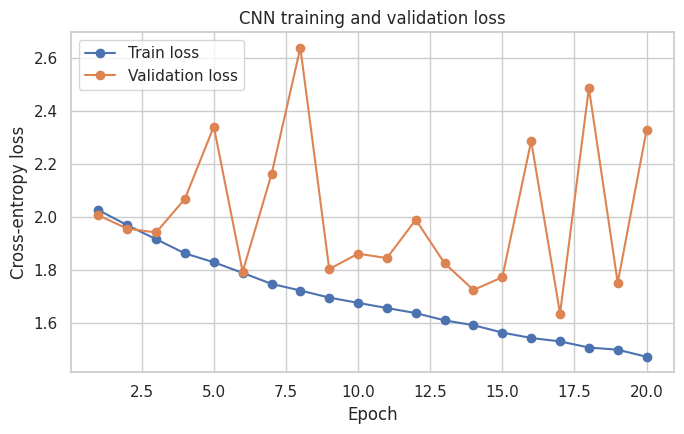

In [43]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
ax.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss")
ax.set_title("CNN training and validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.legend()
plt.tight_layout()

final_acc = history_df["val_acc"].iloc[-1]
final_uar = history_df["val_uar"].iloc[-1]
print(f"Final test accuracy: {final_acc:.3f}")
print(f"Final test UAR:      {final_uar:.3f}")

**CNN comparison:** Compare the printed final CNN UAR and accuracy with the Task 3 model-comparison table. A minimal CNN may underperform eGeMAPS baselines on small datasets because it must learn spectro-temporal filters from limited data. With augmentation, more data, or pretrained audio representations, spectrogram models can become more competitive.

The spectrogram-as-image approach has the advantage of learning task-specific time-frequency patterns directly, instead of relying on a fixed hand-crafted summary. This can capture local prosodic and spectral cues that functionals may average away. Its disadvantage is data hunger: a CNN has many trainable weights and can overfit small emotion datasets such as RAVDESS. eGeMAPS features are compact, interpretable, and designed for affective speech, so they often provide stronger low-data baselines.


## Final Report Checklist

- Filename parser implemented and demonstrated.
- RAVDESS class counts plotted and imbalance discussed.
- Duration mean/std and histogram computed.
- Happy, sad, and angry waveforms plus mel-spectrograms plotted.
- UAR reflection with formula included.
- Single-file and full-dataset eGeMAPS extraction implemented; CSV saved as `ravdess_egemaps.csv`.
- Pitch-by-emotion chart and eGeMAPS correlation heatmap included.
- SVM and Random Forest 10-fold stratified CV implemented with UAR and accuracy.
- Confusion matrix, C comparison, feature importances, and model table included.
- UMAP raw/scaled and `n_neighbors` comparison plots included.
- CNN data pipeline, architecture, parameter count, training loop, loss plot, and final test metrics included.
